In [13]:
# --- SECTION 1: IMPORTS & LOADING PRESAVED DATA ---

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from lifelines.utils import concordance_index
import sys

sys.path.append(r"D:\School\IITD\General\GBM")

from utils import compute_guan_rank, km_plot, concordance, quantize_matrix_fast, cox_regulon

with open(r'D:\School\IITD\General\GBM\saved_data\quantized_matrix_899.pkl', 'rb') as f:
    quantized_matrix_899 = pickle.load(f)

with open(r'D:\School\IITD\General\GBM\saved_data\program_activity.pkl', 'rb') as f:
    program_activity = pickle.load(f)       # (16 x 437)

with open(r'D:\School\IITD\General\GBM\saved_data\program_series.pkl', 'rb') as f:
    program_series = pickle.load(f)         # regulon → program

with open(r'D:\School\IITD\General\GBM\saved_data\state_labels.pkl', 'rb') as f:
    state_series = pickle.load(f)           # patient → state

with open(r'D:\School\IITD\General\GBM\saved_data\clinical_clean.pkl', 'rb') as f:
    clinical_clean = pickle.load(f)         # (437 x 2)

with open(r'D:\School\IITD\General\GBM\saved_data\validated.pkl', 'rb') as f:
    validated = pickle.load(f)              # 899 validated regulons

with open(r'D:\School\IITD\General\GBM\saved_data\gravendeel_aligned.pkl', 'rb') as f:
    gravendeel_aligned = pickle.load(f)

with open(r'D:\School\IITD\General\GBM\saved_data\grav_survival_aligned.pkl', 'rb') as f:
    grav_survival_aligned = pickle.load(f).dropna()

print(f"Program activity: {program_activity.shape}")   # (16, 437)
print(f"State counts:\n{state_series.value_counts()}")
print(f"Clinical: {clinical_clean.shape}")             # (437, 2)

Program activity: (15, 437)
State counts:
0    264
1    173
Name: count, dtype: int64
Clinical: (435, 2)


In [14]:
print(clinical_clean.shape)
print(clinical_clean.head())

(435, 2)
              OS_STATUS  OS_MONTHS
PATIENT_ID                        
TCGA-02-0004          1      11.33
TCGA-02-0015          1      20.60
TCGA-02-0016          1      86.99
TCGA-02-0023          1      20.11
TCGA-02-0025          1      42.71


In [15]:
# --- SECTION 2: GUANRANK COMPUTATION ---

guan_scores = compute_guan_rank(clinical_clean)
print(f"GuanRank scores: {len(guan_scores)}")
print(f"Mean: {guan_scores.mean():.3f}")
print(f"High risk (>0.5): {(guan_scores > 0.5).sum()}")
print(f"Low risk  (<=0.5): {(guan_scores <= 0.5).sum()}")

GuanRank scores: 435
Mean: 0.512
High risk (>0.5): 218
Low risk  (<=0.5): 217


In [16]:
# --- CELL 3: ALIGN PATIENTS + 70/10/20 SPLIT ---

# 70% training — model learns weights
# 10% validation — select optimal number of features
# 20% test — final reported C-index

common_patients = program_activity.columns.intersection(guan_scores.index)
print(f"Common patients: {len(common_patients)}")

X_all    = program_activity[common_patients].T.values  # (435 x 16)
y_all    = guan_scores[common_patients].values
patients = np.array(common_patients)

# First split off 20% test
X_temp, X_test, y_temp, y_test, pat_temp, pat_test = train_test_split(
    X_all, y_all, patients, test_size=0.2, random_state=42
)

# Then split remaining 80% into 70% train and 10% val
# 0.125 x 0.8 = 0.10 of total
X_train, X_val, y_train, y_val, pat_train, pat_val = train_test_split(
    X_temp, y_temp, pat_temp, test_size=0.125, random_state=42
)

print(f"Train: {len(X_train)} patients")
print(f"Val:   {len(X_val)} patients")
print(f"Test:  {len(X_test)} patients")
print(f"Total: {len(X_train) + len(X_val) + len(X_test)} patients")

Common patients: 435
Train: 304 patients
Val:   44 patients
Test:  87 patients
Total: 435 patients


In [17]:
# --- CELL 4: RANK PROGRAMS BY COX P-VALUE ON TRAINING SET ---

# Cox regression on each program's activity across training patients only
# This ensures no data leakage from val/test into feature selection
cox_programs = {}
for prog in program_activity.index:
    eigen = pd.Series(X_train[:, prog], index=pat_train)
    hr, pval = cox_regulon(eigen, clinical_clean.loc[pat_train])
    if hr is not None:
        cox_programs[prog] = {'hr': hr, 'pval': pval}

# Sort programs by p-value — most significant first
program_ranking = sorted(cox_programs.keys(),
                         key=lambda p: cox_programs[p]['pval'])

print(f"Programs ranked by Cox p-value:")
for prog in program_ranking:
    print(f"  Program {prog}: p={cox_programs[prog]['pval']:.4f}  hr={cox_programs[prog]['hr']:.4f}")

Programs ranked by Cox p-value:
  Program 8: p=0.1170  hr=1.2312
  Program 2: p=0.1500  hr=1.1999
  Program 11: p=0.2271  hr=0.8660
  Program 9: p=0.2678  hr=0.8918
  Program 5: p=0.2762  hr=1.1667
  Program 1: p=0.3539  hr=1.1524
  Program 12: p=0.4566  hr=1.0963
  Program 6: p=0.4685  hr=0.9144
  Program 0: p=0.4777  hr=1.1085
  Program 3: p=0.5732  hr=0.9387
  Program 13: p=0.5913  hr=0.9302
  Program 14: p=0.6280  hr=1.0496
  Program 10: p=0.6596  hr=0.9489
  Program 7: p=0.8045  hr=1.0236
  Program 4: p=0.9946  hr=0.9991


n_features=1: val C-index=0.5192
n_features=2: val C-index=0.5422
n_features=3: val C-index=0.5614
n_features=4: val C-index=0.5793
n_features=5: val C-index=0.5934
n_features=6: val C-index=0.5908
n_features=7: val C-index=0.5921
n_features=8: val C-index=0.5972
n_features=9: val C-index=0.6036
n_features=10: val C-index=0.5997
n_features=11: val C-index=0.5997
n_features=12: val C-index=0.5959
n_features=13: val C-index=0.5921
n_features=14: val C-index=0.5934
n_features=15: val C-index=0.5972

Best n_features: 9 (val C-index=0.6036)


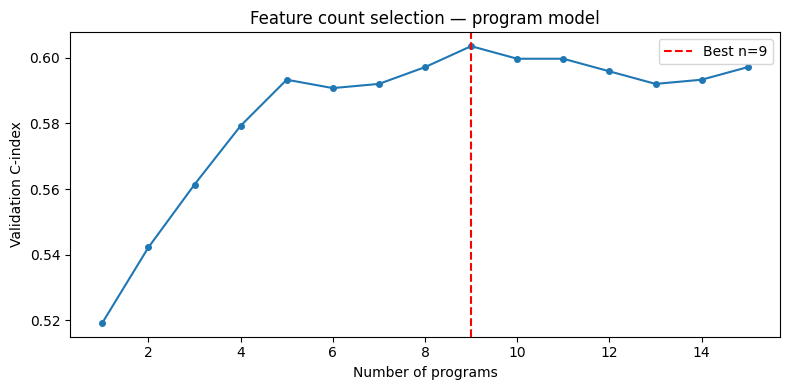

In [18]:
# --- CELL 5: FEATURE COUNT SELECTION ON VALIDATION SET ---

# Try adding one program at a time (ranked by Cox p-value)
# Pick n_features that gives best validation C-index

best_n_features = 1
best_val_ci     = 0
val_ci_scores   = []

for n_features in range(1, len(program_ranking) + 1):
    top_programs = program_ranking[:n_features]

    ridge = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)
    ridge.fit(X_train[:, top_programs], y_train)

    y_pred_val = ridge.predict(X_val[:, top_programs])
    val_ci = concordance_index(
        clinical_clean.loc[pat_val, 'OS_MONTHS'],
        -y_pred_val,
        clinical_clean.loc[pat_val, 'OS_STATUS']
    )
    val_ci_scores.append(val_ci)
    print(f"n_features={n_features}: val C-index={val_ci:.4f}")

    if val_ci > best_val_ci:
        best_val_ci     = val_ci
        best_n_features = n_features

print(f"\nBest n_features: {best_n_features} (val C-index={best_val_ci:.4f})")

# Plot
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(program_ranking) + 1), val_ci_scores, marker='o', markersize=4)
plt.axvline(x=best_n_features, color='red', linestyle='--',
            label=f'Best n={best_n_features}')
plt.xlabel('Number of programs')
plt.ylabel('Validation C-index')
plt.title('Feature count selection — program model')
plt.legend()
plt.tight_layout()
plt.show()

Using top 9 programs: [8, 2, 11, 9, 5, 1, 12, 6, 0]
Program model — Test C-index: 0.5097


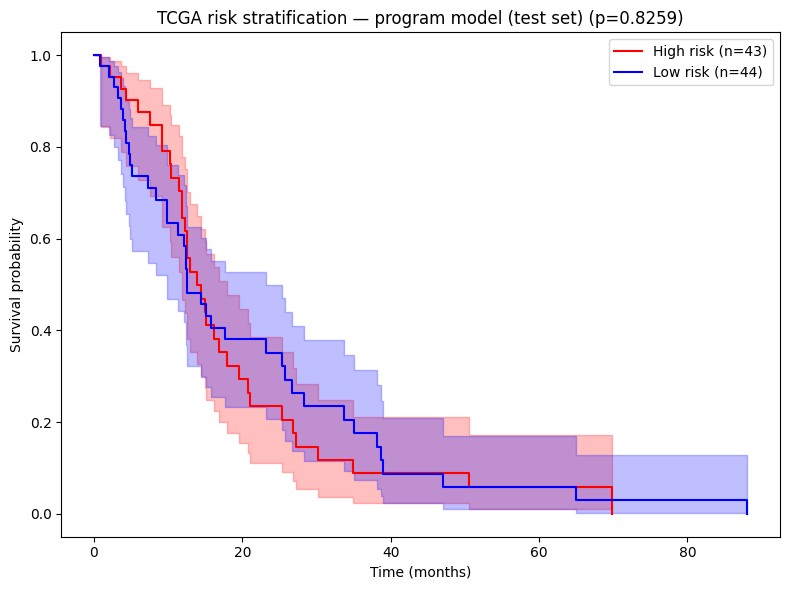

Log-rank p-value: 8.2586e-01


In [33]:
# --- CELL 6: TRAIN FINAL PROGRAM MODEL + TEST C-INDEX ---

top_programs = program_ranking[:best_n_features]
print(f"Using top {best_n_features} programs: {top_programs}")

ridge_program = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)
ridge_program.fit(X_train[:, top_programs], y_train)

y_pred_test = ridge_program.predict(X_test[:, top_programs])
ci_test_program = concordance_index(
    clinical_clean.loc[pat_test, 'OS_MONTHS'],
    -y_pred_test,
    clinical_clean.loc[pat_test, 'OS_STATUS']
)
print(f"Program model — Test C-index: {ci_test_program:.4f}")

# KM plot on test set
test_risk_scores = pd.Series(y_pred_test, index=pat_test)
p_tcga_program = km_plot(
    test_risk_scores,
    clinical_clean,
    title='TCGA risk stratification — program model (test set)',
    save_path=r"D:\School\IITD\General\GBM\results\km_tcga_program.png"
)

In [22]:
# --- CELL 7: REGULON MODEL — DATA PREP + SPLIT ---

common_patients_reg = quantized_matrix_899.columns.intersection(guan_scores.index)
X_reg        = quantized_matrix_899[common_patients_reg].T.values  # (435 x 899)
y_reg        = guan_scores[common_patients_reg].values
patients_reg = np.array(common_patients_reg)

X_temp_r, X_test_r, y_temp_r, y_test_r, pat_temp_r, pat_test_r = train_test_split(
    X_reg, y_reg, patients_reg, test_size=0.2, random_state=42
)
X_train_r, X_val_r, y_train_r, y_val_r, pat_train_r, pat_val_r = train_test_split(
    X_temp_r, y_temp_r, pat_temp_r, test_size=0.125, random_state=42
)

print(f"Regulon model — Train: {len(X_train_r)}, Val: {len(X_val_r)}, Test: {len(X_test_r)}")

Regulon model — Train: 304, Val: 44, Test: 87


In [24]:
# --- CELL 8: RANK REGULONS BY COX P-VALUE ON TRAINING SET ---

cox_reg_results = {}
for idx in range(len(validated)):
    eigen = pd.Series(X_train_r[:, idx], index=pat_train_r)
    hr, pval = cox_regulon(eigen, clinical_clean.loc[pat_train_r])
    if hr is not None:
        cox_reg_results[idx] = {'hr': hr, 'pval': pval}
    if idx % 100 == 0:
        print(f"Cox regression {idx}/{len(validated)}...")

regulon_ranking = sorted(cox_reg_results.keys(),
                         key=lambda r: cox_reg_results[r]['pval'])
print(f"Regulons ranked: {len(regulon_ranking)}")

Cox regression 0/899...
Cox regression 100/899...
Cox regression 200/899...
Cox regression 300/899...
Cox regression 400/899...
Cox regression 500/899...
Cox regression 600/899...
Cox regression 700/899...
Cox regression 800/899...
Regulons ranked: 899


n_regulons=10: val C-index=0.5844
n_regulons=20: val C-index=0.5985
n_regulons=50: val C-index=0.5997
n_regulons=100: val C-index=0.6368
n_regulons=148: val C-index=0.6228
n_regulons=200: val C-index=0.6394
n_regulons=300: val C-index=0.6215
n_regulons=500: val C-index=0.6279
n_regulons=899: val C-index=0.6381

Best n_regulons: 200 (val C-index=0.6394)


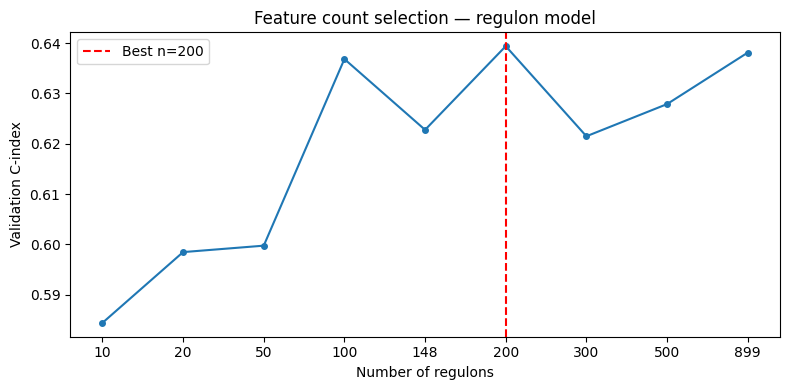

In [26]:
# --- CELL 9: FEATURE COUNT SELECTION (REGULON MODEL) ---

best_n_reg    = 1
best_val_ci_r = 0
val_ci_reg    = []
candidates    = [10, 20, 50, 100, 148, 200, 300, 500, len(regulon_ranking)]

for n_features in candidates:
    if n_features > len(regulon_ranking):
        break
    top_regs = regulon_ranking[:n_features]

    ridge = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)
    ridge.fit(X_train_r[:, top_regs], y_train_r)

    y_pred_val = ridge.predict(X_val_r[:, top_regs])
    val_ci = concordance_index(
        clinical_clean.loc[pat_val_r, 'OS_MONTHS'],
        -y_pred_val,
        clinical_clean.loc[pat_val_r, 'OS_STATUS']
    )
    val_ci_reg.append(val_ci)
    print(f"n_regulons={n_features}: val C-index={val_ci:.4f}")

    if val_ci > best_val_ci_r:
        best_val_ci_r = val_ci
        best_n_reg    = n_features

print(f"\nBest n_regulons: {best_n_reg} (val C-index={best_val_ci_r:.4f})")

plt.figure(figsize=(8, 4))
plt.plot(range(len(val_ci_reg)), val_ci_reg, marker='o', markersize=4)
plt.xticks(range(len(candidates[:len(val_ci_reg)])), candidates[:len(val_ci_reg)])
plt.axvline(x=candidates.index(best_n_reg), color='red', linestyle='--',
            label=f'Best n={best_n_reg}')
plt.xlabel('Number of regulons')
plt.ylabel('Validation C-index')
plt.title('Feature count selection — regulon model')
plt.legend(); plt.tight_layout(); plt.show()

Regulon model — Test C-index: 0.5764


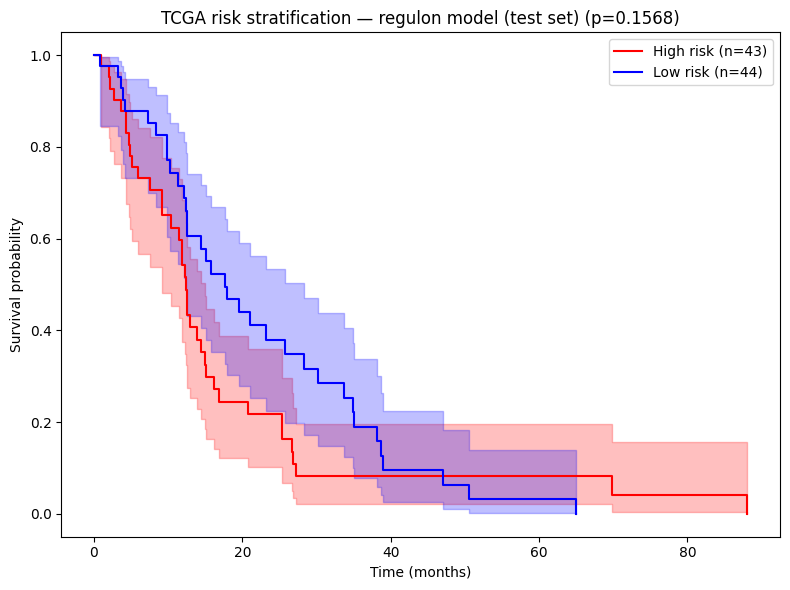

Log-rank p-value: 1.5676e-01


In [30]:
# --- CELL 10: TRAIN FINAL REGULON MODEL + TEST C-INDEX ---

top_regs_final = regulon_ranking[:best_n_reg]

ridge_regulon  = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)
ridge_regulon.fit(X_train_r[:, top_regs_final], y_train_r)

y_pred_test_r   = ridge_regulon.predict(X_test_r[:, top_regs_final])
ci_test_regulon = concordance_index(
    clinical_clean.loc[pat_test_r, 'OS_MONTHS'],
    -y_pred_test_r,
    clinical_clean.loc[pat_test_r, 'OS_STATUS']
)
print(f"Regulon model — Test C-index: {ci_test_regulon:.4f}")

test_risk_scores_r = pd.Series(y_pred_test_r, index=pat_test_r)
p_tcga_regulon     = km_plot(
    test_risk_scores_r,
    clinical_clean,
    title='TCGA risk stratification — regulon model (test set)',
    save_path='km_tcga_regulon.png'
)

In [34]:
# --- CELL 11: COMPARE TCGA MODELS ---

print(f"{'Model':<15} {'Test C-index':<15} {'KM p-value'}")
print("-" * 45)
print(f"{'Program':<15} {ci_test_program:<15.4f} {p_tcga_program:.4e}")
print(f"{'Regulon':<15} {ci_test_regulon:<15.4f} {p_tcga_regulon:.4e}")

Model           Test C-index    KM p-value
---------------------------------------------
Program         0.5097          8.2586e-01
Regulon         0.5764          1.5676e-01


In [35]:
# --- CELL 12: QUANTIZE GRAVENDEEL ---

grav_quantized = quantize_matrix_fast(
    gravendeel_aligned,
    list(range(len(validated))),
    validated
)
print(f"Gravendeel quantized: {grav_quantized.shape}")
print(pd.Series(grav_quantized.values.flatten()).value_counts())

Patient 0/252...
Patient 50/252...
Patient 100/252...
Patient 150/252...
Patient 200/252...
Patient 250/252...
Gravendeel quantized: (895, 252)
 0    171809
 1     27789
-1     25942
Name: count, dtype: int64


Common Gravendeel patients: 252


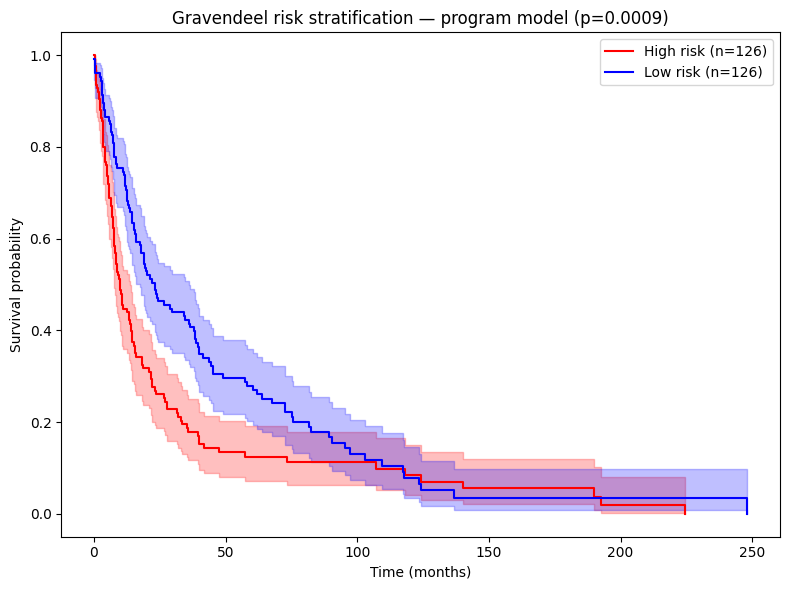

Log-rank p-value: 9.4233e-04
Gravendeel — Program model C-index: 0.6230


In [37]:
# --- CELL 13: GRAVENDEEL PROGRAM ACTIVITY + EVALUATION ---

n_programs = program_activity.shape[0]
grav_program_activity = pd.DataFrame(
    index=range(n_programs),
    columns=grav_quantized.columns
)

for prog in range(n_programs):
    regs_in_prog   = program_series[program_series == prog].index.tolist()
    regs_available = [r for r in regs_in_prog if r in grav_quantized.index]
    if len(regs_available) > 0:
        grav_program_activity.loc[prog] = grav_quantized.loc[regs_available].mean(axis=0)
    else:
        grav_program_activity.loc[prog] = 0

grav_program_activity = grav_program_activity.astype(float)

common_grav     = grav_program_activity.columns.intersection(grav_survival_aligned.index)
print(f"Common Gravendeel patients: {len(common_grav)}")

X_grav_prog      = grav_program_activity[common_grav].T.values[:, top_programs]
y_pred_grav_prog = ridge_program.predict(X_grav_prog)
grav_risk_prog   = pd.Series(y_pred_grav_prog, index=common_grav)

ci_grav_program = concordance(grav_risk_prog, grav_survival_aligned)
p_grav_program  = km_plot(
    grav_risk_prog,
    grav_survival_aligned,
    title='Gravendeel risk stratification — program model',
    save_path='km_gravendeel_program.png'
)
print(f"Gravendeel — Program model C-index: {ci_grav_program:.4f}")

Top regulons available in Gravendeel: 199 of 200


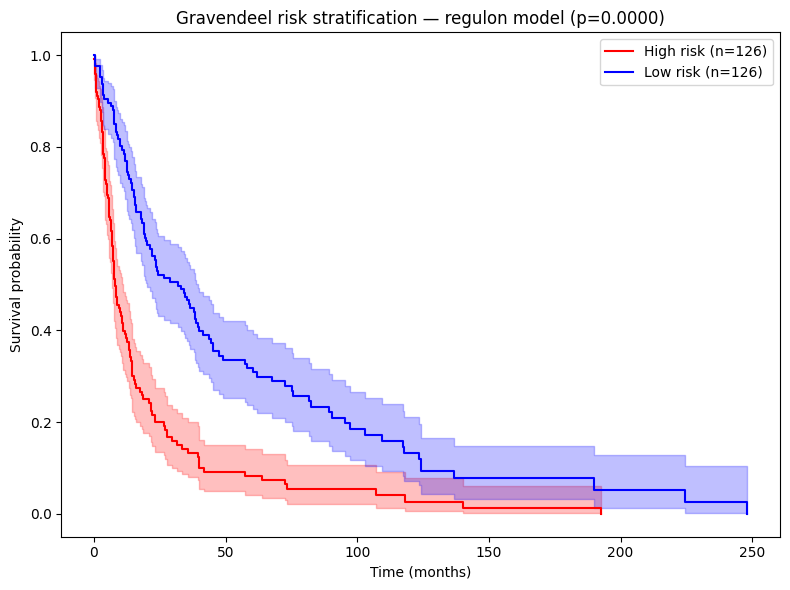

Log-rank p-value: 5.5968e-11
Gravendeel — Regulon model C-index: 0.6582


In [38]:
# --- CELL 14: GRAVENDEEL REGULON MODEL EVALUATION ---

common_grav_reg  = grav_quantized.columns.intersection(grav_survival_aligned.index)

top_regs_grav    = [r for r in top_regs_final if r in grav_quantized.index]
print(f"Top regulons available in Gravendeel: {len(top_regs_grav)} of {len(top_regs_final)}")

ridge_regulon_grav = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)
ridge_regulon_grav.fit(X_train_r[:, top_regs_grav], y_train_r)

X_grav_reg      = grav_quantized.loc[top_regs_grav, common_grav_reg].T.values
y_pred_grav_reg = ridge_regulon_grav.predict(X_grav_reg)
grav_risk_reg   = pd.Series(y_pred_grav_reg, index=common_grav_reg)

ci_grav_regulon = concordance(grav_risk_reg, grav_survival_aligned)
p_grav_regulon  = km_plot(
    grav_risk_reg,
    grav_survival_aligned,
    title='Gravendeel risk stratification — regulon model',
    save_path='km_gravendeel_regulon.png'
)
print(f"Gravendeel — Regulon model C-index: {ci_grav_regulon:.4f}")

In [39]:
# --- CELL 15: FINAL RESULTS SUMMARY ---

print(f"{'Model':<15} {'TCGA C-index':<15} {'TCGA KM p':<15} {'Grav C-index':<15} {'Grav KM p'}")
print("-" * 70)
print(f"{'Program':<15} {ci_test_program:<15.4f} {p_tcga_program:<15.4e} {ci_grav_program:<15.4f} {p_grav_program:.4e}")
print(f"{'Regulon':<15} {ci_test_regulon:<15.4f} {p_tcga_regulon:<15.4e} {ci_grav_regulon:<15.4f} {p_grav_regulon:.4e}")

Model           TCGA C-index    TCGA KM p       Grav C-index    Grav KM p
----------------------------------------------------------------------
Program         0.5097          8.2586e-01      0.6230          9.4233e-04
Regulon         0.5764          1.5676e-01      0.6582          5.5968e-11
